# Class 6 — FDE Data Validation with FlashEats

Yesterday, you proved you could **retrieve** data from multiple systems.

Today the question is different:

> **Can we safely use that data to make a business decision?**

This is not a generic data-cleaning lab.

## FDE validation mindset

**Business claim → assumptions → validation contract → targeted checks → stakeholder clarification → PASS / WARN / FAIL → publish decision**

### Concepts

**1. Validation is decision-dependent**  
A field can be good enough for weekly reporting but unsafe for a live operational decision.

**2. Turn assumptions into contracts**  
Business assumption → data expectation → executable check → action.

**3. Separate three validation types**
- Technical: chronology, IDs, categories, mappings
- Semantic: what does a status or ETA actually mean?
- Organizational: who owns the KPI definition?

**4. Never silently fix ambiguity**  
Do not encode thresholds or category mappings without ownership.

**5. Output a validation gate**  
The deliverable is not merely a cleaned dataframe. It is a decision:
PASS / WARN / FAIL / UNKNOWN.

In [1]:
import json
import sqlite3
import zipfile
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

# ------------------------------------------------------------
# Robust pack discovery for Colab / local runs
# ------------------------------------------------------------

def find_pack_root(search_root=Path("/content")):
    candidates = list(search_root.rglob("FlashEats_Classroom_Pack_V2"))
    for candidate in candidates:
        db = candidate / "database" / "flasheats.db"
        if db.exists():
            return candidate
    return None

# Local run: the notebook usually already lives inside the pack root.
BASE = None
if (Path.cwd() / "database" / "flasheats.db").exists():
    BASE = Path.cwd()
elif Path.cwd().name == "FlashEats_Classroom_Pack_V2":
    BASE = Path.cwd()

if BASE is None:
    BASE = find_pack_root()

if BASE is None:
    try:
        from google.colab import files

        print("Upload: FlashEats_Class6_Classroom_Pack.zip")
        uploaded = files.upload()

        zip_name = next(name for name in uploaded if name.endswith(".zip"))

        extract_dir = Path("/content/flasheats_class6")
        extract_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(zip_name, "r") as z:
            z.extractall(extract_dir)

        BASE = find_pack_root(Path("/content"))

    except Exception as e:
        print("Automatic Colab setup failed:", e)

# Local fallback: search current working directory too
if BASE is None:
    BASE = find_pack_root(Path.cwd())

print("Detected BASE:", BASE)

if BASE is None:
    raise FileNotFoundError(
        "Could not find FlashEats_Classroom_Pack_V2. "
        "Upload/extract the classroom pack ZIP, then rerun this cell."
    )

DB_PATH = BASE / "database" / "flasheats.db"

print("Database path:", DB_PATH)
print("Database exists:", DB_PATH.exists())

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found at {DB_PATH}")

Detected BASE: C:\Users\Ishan Ganguly\Downloads\FlashEats_Classwork_Classes_5-8\FlashEats_Classwork_Classes_5-8\Class6
Database path: C:\Users\Ishan Ganguly\Downloads\FlashEats_Classwork_Classes_5-8\FlashEats_Classwork_Classes_5-8\Class6\database\flasheats.db
Database exists: True


## Load the updated FlashEats data

In [2]:
con = sqlite3.connect(BASE / "database" / "flasheats.db")

orders = pd.read_sql("SELECT * FROM orders", con)
restaurants = pd.read_sql("SELECT * FROM restaurants", con)
drivers = pd.read_sql("SELECT * FROM drivers", con)

tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")

with open(BASE / "data" / "client_metric_definitions.json", "r") as f:
    metric_notes = json.load(f)

print("orders:", orders.shape)
print("tickets:", tickets.shape)
print("restaurant_status:", restaurant_status.shape)

display(orders.head())
display(tickets.head())
display(restaurant_status.head())
print(json.dumps(metric_notes, indent=2))

orders: (1603, 13)
tickets: (202, 5)
restaurant_status: (502, 4)


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,None,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


,order_id,restaurant_id,status,last_updated_at
0,O00676,R040,READY,2026-08-17T13:29:00
1,O01506,R055,Ready,2026-08-27T16:37:00
2,O01484,R032,ready,2026-08-08T19:44:00
3,O00675,R012,handoff,2026-08-22T21:42:00
4,O00078,R027,unknown,2026-08-25T19:35:00


{
  "metric_under_review": "Late Delivery Rate",
  "leadership_claim": "Late Delivery Rate is 56%",
  "stakeholders": {
    "VP Operations": "Any delivered order after the promised ETA is late.",
    "Support Lead": "Only more than 10 minutes beyond ETA should count as meaningfully late.",
    "Finance": "Cancelled/refunded orders should not count in operational performance.",
    "Data Team": "Historical dashboard uses delivered orders with non-null actual delivery time."
  },
  "note": "No canonical KPI owner is formally documented."
}


# Challenge 1 — Can we defend the “56% late” claim?

Leadership says:

> **“Late Delivery Rate is 56%.”**

Before calculating anything, create a validation contract.

**Hint:** Don't start by cleaning. Ask: *what could make 56% misleading?*

### Validation contract (written before running the checks)

| Business assumption | Data expectation | How will you test it? | Severity if false |
|---|---|---|---|
| One row = one business order | `order_id` is unique in `orders`; if repeated, the copies are identical | Count rows vs unique IDs; compare every column across duplicate copies | **Medium** — inflates the denominator; conflicting copies make segment analysis arbitrary |
| Delivered orders have completion time | Every order whose status means *delivered* has a non-null `actual_delivery_at` | Normalise status for *counting only*, then count delivered orders with null completion | **High** — these orders cannot be classified late/on-time at all |
| Promised ETA is valid | `promised_eta` parses and is after `created_at` | Parse with `errors="coerce"`; count unparseable values and ETAs before order creation | **High** — lateness is measured against this field |
| Event chronology is valid | `created_at ≤ pickup_at ≤ actual_delivery_at` | Count rows violating each step | **Medium** — impossible rows point to clock or logging defects |
| “Late” has an agreed definition | One documented definition, one named owner | Read `client_metric_definitions.json`; compute the rate under each definition | **Critical** — if the number changes with the definition, the claim is not yet meaningful |


In [3]:
print("Rows:", len(orders))
print("Unique orders:", orders["order_id"].nunique())
print(orders["final_status"].value_counts(dropna=False))

TS_COLS = ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]

# --- 1. Business grain -------------------------------------------------------
dup_rows = orders[orders["order_id"].duplicated(keep=False)].sort_values("order_id")
print("\nExtra duplicate rows:", len(orders) - orders["order_id"].nunique())

conflicts = []
for oid, g in dup_rows.groupby("order_id"):
    differing = [c for c in g.columns if g[c].nunique(dropna=False) > 1]
    conflicts.append({"order_id": oid, "differing_columns": differing,
                      "values": g[differing].to_dict("list")})
print("Duplicate copies are NOT identical:")
display(pd.DataFrame(conflicts))

# --- 2. Parse timestamps (coerce, then COUNT what failed — never drop silently)
chk = orders.drop_duplicates("order_id", keep="first").copy()
for c in TS_COLS:
    parsed = pd.to_datetime(chk[c], format="mixed", errors="coerce")
    unparseable = (chk[c].notna() & parsed.isna()).sum()
    print(f"{c}: nulls={chk[c].isna().sum()}, unparseable={unparseable}")
    chk[c] = parsed

# Status normalised for COUNTING only (case/whitespace = representation)
status_norm = chk["final_status"].str.strip().str.lower()

# --- 3. Delivered orders missing completion time ----------------------------
missing_completion = chk[(status_norm == "delivered") & chk["actual_delivery_at"].isna()]
print("\nDelivered orders with no actual_delivery_at:", len(missing_completion))
print("Cancelled orders with a delivery time (contradiction):",
      ((status_norm == "cancelled") & chk["actual_delivery_at"].notna()).sum())

# --- 4. Promised ETA validity -----------------------------------------------
eta_before_created = chk[chk["promised_eta"] < chk["created_at"]]
print("\nPromised ETA earlier than order creation:", len(eta_before_created))
display(eta_before_created[["order_id", "created_at", "promised_eta", "final_status"]])

# --- 5. Chronology ----------------------------------------------------------
pickup_before_created = chk[chk["pickup_at"] < chk["created_at"]]
delivered_before_pickup = chk[chk["actual_delivery_at"] < chk["pickup_at"]]
print("Pickup before creation:", len(pickup_before_created))
print("Delivered before pickup:", len(delivered_before_pickup))
display(delivered_before_pickup[["order_id", "pickup_at", "actual_delivery_at"]]
        .assign(gap_min=lambda d: (d["actual_delivery_at"] - d["pickup_at"]).dt.total_seconds() / 60))

# --- 6. Which assumptions need a stakeholder? -------------------------------
contract_results = pd.DataFrame([
    ["One row = one business order", f"{len(orders) - orders['order_id'].nunique()} extra rows; copies conflict on traffic_bucket", "Data Team: which copy is authoritative?"],
    ["Delivered orders have completion time", f"{len(missing_completion)} delivered orders have no completion time", "Order platform owner: why was delivery not recorded?"],
    ["Promised ETA is valid", f"{len(eta_before_created)} ETAs precede order creation (all exactly -10 min)", "Dispatch: which ETA is 'promised' — original or updated?"],
    ["Event chronology is valid", f"{len(delivered_before_pickup)} deliveries precede pickup (all exactly -5 min)", "Platform engineering: clock/offset defect?"],
    ["'Late' has an agreed definition", "4 stakeholder definitions, no owner", "Leadership: name a KPI owner"],
], columns=["assumption", "result", "needs clarification from"])
display(contract_results)


Rows: 1603
Unique orders: 1600
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64

Extra duplicate rows: 3
Duplicate copies are NOT identical:


,order_id,differing_columns,values
0,O00120,[traffic_bucket],"{'traffic_bucket': ['severe', 'medium']}"
1,O00723,[traffic_bucket],"{'traffic_bucket': ['medium', 'high']}"
2,O01302,[traffic_bucket],"{'traffic_bucket': ['medium', 'high']}"


created_at: nulls=0, unparseable=0
promised_eta: nulls=0, unparseable=0
pickup_at: nulls=0, unparseable=0
actual_delivery_at: nulls=105, unparseable=0

Delivered orders with no actual_delivery_at: 37
Cancelled orders with a delivery time (contradiction): 0

Promised ETA earlier than order creation: 4


,order_id,created_at,promised_eta,final_status
100,O00101,2026-08-24 20:59:00,2026-08-24 20:49:00,delivered
101,O00102,2026-08-11 16:41:00,2026-08-11 16:31:00,delivered
102,O00103,2026-08-22 20:11:00,2026-08-22 20:01:00,delivered
103,O00104,2026-08-09 22:19:00,2026-08-09 22:09:00,delivered


Pickup before creation: 0
Delivered before pickup: 5


,order_id,pickup_at,actual_delivery_at,gap_min
50,O00051,2026-08-01 16:24:51.495665,2026-08-01 16:19:51.495665,-5.0
51,O00052,2026-08-24 18:16:16.946011,2026-08-24 18:11:16.946011,-5.0
52,O00053,2026-08-13 18:25:53.797613,2026-08-13 18:20:53.797613,-5.0
53,O00054,2026-08-28 21:25:10.582862,2026-08-28 21:20:10.582862,-5.0
54,O00055,2026-08-16 14:08:05.645770,2026-08-16 14:03:05.645770,-5.0


,assumption,result,needs clarification from
0,One row = one business order,3 extra rows; copies conflict on traffic_bucket,Data Team: which copy is authoritative?
1,Delivered orders have completion time,37 delivered orders have no completion time,Order platform owner: why was delivery not recorded?
2,Promised ETA is valid,4 ETAs precede order creation (all exactly -10 min),Dispatch: which ETA is 'promised' — original or updated?
3,Event chronology is valid,5 deliveries precede pickup (all exactly -5 min),Platform engineering: clock/offset defect?
4,'Late' has an agreed definition,"4 stakeholder definitions, no owner",Leadership: name a KPI owner


### Challenge 1 findings

- **Grain:** 1,603 rows for 1,600 orders. The 3 duplicate copies **are not identical** — each pair disagrees on `traffic_bucket` (e.g. O00120 is both `severe` and `medium`). `keep="first"` does not change the late rate, but it silently decides which traffic bucket each order counts under in any "traffic is the problem" analysis. That choice is arbitrary until the Data Team says which copy is authoritative.
- **Completion:** 37 delivered orders have no completion time. They cannot be classified as late or on time, so they are **excluded from the denominator and reported separately** rather than silently dropped.
- **ETA:** 4 orders have a promised ETA exactly 10 minutes *before* the order was created. The identical offset suggests a systematic defect (timezone or field-mapping), not random noise.
- **Chronology:** 5 orders were "delivered" exactly 5 minutes before pickup — again a fixed offset, so likely a clock or logging bug.
- **Definition:** untested so far — it is the biggest risk, and it is Challenge 2.

None of these technical issues is large. The question is whether they *move the number* — that is answered below.


# Challenge 2 — Stakeholders disagree on “late”

Read `client_metric_definitions.json`.

Calculate the metric under at least three definitions:
- any delay > 0 minutes,
- delay > 10 minutes,
- historical-style delivered/non-null population.

Then answer:

> **Which one should leadership publish, and who must own that decision?**


,definition,stakeholder,late,denominator,late_rate_%,business_meaning
0,Any delay > 0 min,VP Operations,843,1495,56.4,Did we keep the exact promise we showed the customer?
1,Delay > 10 min,Support Lead,349,1495,23.3,How often is the delay big enough that customers complain?
2,"Historical dashboard (exact 'delivered', non-null)",Data Team,840,1490,56.4,Continuity with the existing dashboard; silently drops 5 'Delivered' rows
3,"Any delay > 0, all orders incl. cancelled as denominator",(nobody — shown for contrast),843,1600,52.7,What happens if the denominator is not pinned down


,scenario,late_rate_%
0,"Headline (any delay, normalised status)",56.4
1,Excluding 9 chronology-invalid rows,56.3
2,Lower bound: all 37 missing-completion orders were on time,55.0
3,Upper bound: all 37 missing-completion orders were late,57.4
4,No de-duplication at all,56.3


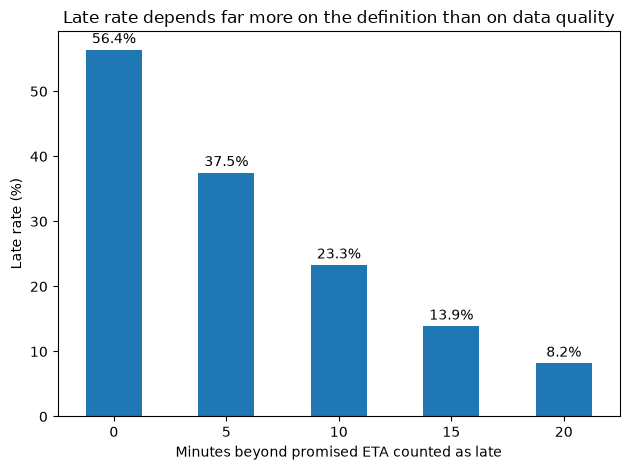

Median lateness among late orders: 8.0 min


In [4]:
analysis = orders.drop_duplicates("order_id", keep="first").copy()

for c in ["promised_eta", "actual_delivery_at"]:
    analysis[c] = pd.to_datetime(analysis[c], format="mixed", errors="coerce")

analysis["delay_min"] = (
    analysis["actual_delivery_at"] - analysis["promised_eta"]
).dt.total_seconds() / 60


for c in ["created_at", "pickup_at"]:
    analysis[c] = pd.to_datetime(analysis[c], format="mixed", errors="coerce")

status_norm = analysis["final_status"].str.strip().str.lower()

# Population: delivered (case-normalised) with a completion time.
# Cancelled orders are excluded — this satisfies Finance's rule in every definition below.
delivered = analysis[(status_norm == "delivered") & analysis["actual_delivery_at"].notna()]

# Data Team's historical dashboard: exact string 'delivered' + non-null completion time
historical = analysis[(analysis["final_status"] == "delivered") & analysis["actual_delivery_at"].notna()]

def late_rate(df, threshold=0, denominator=None):
    n = len(df) if denominator is None else denominator
    k = int((df["delay_min"] > threshold).sum())
    return k, n, round(100 * k / n, 1)

rows = []
def add(name, owner, df, threshold=0, denominator=None, meaning=""):
    k, n, pct = late_rate(df, threshold, denominator)
    rows.append({"definition": name, "stakeholder": owner, "late": k, "denominator": n,
                 "late_rate_%": pct, "business_meaning": meaning})

add("Any delay > 0 min", "VP Operations", delivered, 0,
    meaning="Did we keep the exact promise we showed the customer?")
add("Delay > 10 min", "Support Lead", delivered, 10,
    meaning="How often is the delay big enough that customers complain?")
add("Historical dashboard (exact 'delivered', non-null)", "Data Team", historical, 0,
    meaning="Continuity with the existing dashboard; silently drops 5 'Delivered' rows")
add("Any delay > 0, all orders incl. cancelled as denominator", "(nobody — shown for contrast)", delivered, 0,
    denominator=len(analysis),
    meaning="What happens if the denominator is not pinned down")

definitions = pd.DataFrame(rows)
display(definitions)

# --- Sensitivity: do the DATA issues move the number? ------------------------
k, n, _ = late_rate(delivered)
n_missing = int(((status_norm == "delivered") & analysis["actual_delivery_at"].isna()).sum())
bad_chrono = ((delivered["actual_delivery_at"] < delivered["pickup_at"]) |
              (delivered["promised_eta"] < delivered["created_at"]))

sensitivity = pd.DataFrame([
    ["Headline (any delay, normalised status)", late_rate(delivered)[2]],
    ["Excluding 9 chronology-invalid rows", late_rate(delivered[~bad_chrono])[2]],
    [f"Lower bound: all {n_missing} missing-completion orders were on time", round(100 * k / (n + n_missing), 1)],
    [f"Upper bound: all {n_missing} missing-completion orders were late", round(100 * (k + n_missing) / (n + n_missing), 1)],
    ["No de-duplication at all", round(100 * (orders.assign(
        p=pd.to_datetime(orders["promised_eta"], format="mixed"),
        x=pd.to_datetime(orders["actual_delivery_at"], format="mixed"))
        .query("final_status == 'delivered' and x.notna()")
        .eval("x > p").mean()), 1)],
], columns=["scenario", "late_rate_%"])
display(sensitivity)

# --- Threshold curve: how sensitive is the metric to the definition? ---------
thresholds = [0, 5, 10, 15, 20]
curve = pd.Series({t: late_rate(delivered, t)[2] for t in thresholds}, name="late_rate_%")
ax = curve.plot(kind="bar", rot=0)
ax.set_title("Late rate depends far more on the definition than on data quality")
ax.set_xlabel("Minutes beyond promised ETA counted as late")
ax.set_ylabel("Late rate (%)")
for i, v in enumerate(curve):
    ax.text(i, v + 1, f"{v}%", ha="center")
plt.tight_layout()
plt.show()

print("Median lateness among late orders:",
      round(delivered.loc[delivered["delay_min"] > 0, "delay_min"].median(), 1), "min")


### Challenge 2 findings

| Definition | Late rate | Business meaning |
|---|---:|---|
| Any delay > 0 min (VP Ops) | **56.4%** (843 / 1,495) | Did we keep the exact promise shown to the customer? |
| Delay > 10 min (Support Lead) | **23.3%** (349 / 1,495) | How often is the delay large enough to hurt the customer? |
| Historical dashboard (Data Team) | **56.4%** (840 / 1,490) | Same rate, but a case-sensitive filter silently drops 5 `Delivered` orders |
| All orders as denominator | 52.7% (843 / 1,600) | Shows how much the number moves if nobody fixes the denominator |

Finance's rule (exclude cancelled orders) is already applied in the first three rows, so it does not produce a competing number — it pins down the denominator.

**The key finding:** every data-quality scenario keeps the rate between **55.0% and 57.4%**. The *definition* moves it from **56.4% to 23.3%**. So the "56%" figure is **technically reproducible but semantically undefined**: leadership has quoted the strictest possible definition without saying so. Median lateness among late orders is only about 8 minutes, meaning most "late" orders are only slightly late.

**Which should leadership publish?** Recommended: publish **both, labelled** — "56.4% of delivered orders arrived after the promised ETA; 23.3% arrived more than 10 minutes late." The first measures promise accuracy (an ETA-model problem); the second measures customer-felt delay (an operations problem). Publishing only "56%" invites the wrong intervention.

**Who must own it?** The **VP Operations** is the outcome owner and should ratify the definition, with the **Data Team as the steward** who implements and documents it. Until a named owner signs off, the definition row in the validation gate stays **FAIL** — this is an organisational gap, not a technical one.


# Challenge 3 — Validate categories without cleaning by instinct


Inspect:
- `final_status`
- `traffic_bucket`
- restaurant `status`
- support-ticket `category`

For each:
1. list observed values,
2. identify representation differences,
3. decide what is safe to normalize,
4. identify what requires owner confirmation.

Remember:

> `"Delivered"` vs `"delivered"` is likely representation.  
> `"handoff"` vs `"handed_off"` may be semantics.

In [5]:
for col in ["final_status", "traffic_bucket"]:
    print("\n", col)
    print(orders[col].value_counts(dropna=False))

print("\nRestaurant status")
print(restaurant_status["status"].value_counts(dropna=False))

print("\nSupport category")
print(tickets["category"].value_counts(dropna=False))

# ---------------------------------------------------------------------------
# Classify each observed value: representation vs semantics
# ---------------------------------------------------------------------------
def classify(series, canonical, confirm):
    """canonical: values that are already correct.
    confirm: raw values whose MEANING needs an owner (never mapped automatically)."""
    out = []
    for raw, n in series.value_counts(dropna=False).items():
        key = raw.strip().lower() if isinstance(raw, str) else raw
        if raw in canonical:
            verdict, proposed = "canonical", raw
        elif raw in confirm:
            verdict, proposed = "NEEDS OWNER", confirm[raw]
        elif key in canonical:
            verdict, proposed = "safe to normalise (case/whitespace)", key
        else:
            verdict, proposed = "NEEDS OWNER", "?"
        out.append({"raw_value": repr(raw), "rows": n, "verdict": verdict, "proposed": proposed})
    return pd.DataFrame(out)

print("final_status")
display(classify(orders["final_status"], {"delivered", "cancelled"}, {}))

print("traffic_bucket")
display(classify(orders["traffic_bucket"], {"low", "medium", "high", "severe"}, {}))

print("restaurant status")
display(classify(restaurant_status["status"], {"preparing", "ready", "handed_off"},
                 {"handoff": "handed_off? (or a different step)",
                  "unknown": "keep as unknown — do not guess"}))

print("support ticket category")
display(classify(tickets["category"],
                 {"late_delivery", "eta_changed", "restaurant_delay",
                  "ready_but_waiting", "status_mismatch", "driver_not_moving"},
                 {"Late Delivery": "late_delivery (probably — different tool?)",
                  "ETA issue": "eta_changed? — broader than 'changed'"}))

# Keep an audit column instead of overwriting raw values
restaurant_status["status_raw"] = restaurant_status["status"]
restaurant_status["status_clean"] = restaurant_status["status"].str.strip().str.lower()
print("Representation-only fixes applied to a NEW column; 'handoff' and 'unknown' left untouched:")
display(restaurant_status["status_clean"].value_counts())



 final_status
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64

 traffic_bucket
traffic_bucket
medium    635
high      448
low       381
severe    136
HIGH        3
Name: count, dtype: int64

Restaurant status
status
preparing     171
handed_off    168
ready         157
ready           2
handoff         1
Ready           1
READY           1
unknown         1
Name: count, dtype: int64

Support category
category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64
final_status


,raw_value,rows,verdict,proposed
0,'delivered',1530,canonical,delivered
1,'cancelled',68,canonical,cancelled
2,'Delivered',5,safe to normalise (case/whitespace),delivered


traffic_bucket


,raw_value,rows,verdict,proposed
0,'medium',635,canonical,medium
1,'high',448,canonical,high
2,'low',381,canonical,low
3,'severe',136,canonical,severe
4,'HIGH',3,safe to normalise (case/whitespace),high


restaurant status


,raw_value,rows,verdict,proposed
0,'preparing',171,canonical,preparing
1,'handed_off',168,canonical,handed_off
2,'ready',157,canonical,ready
3,'ready ',2,safe to normalise (case/whitespace),ready
4,'handoff',1,NEEDS OWNER,handed_off? (or a different step)
5,'Ready',1,safe to normalise (case/whitespace),ready
6,'READY',1,safe to normalise (case/whitespace),ready
7,'unknown',1,NEEDS OWNER,keep as unknown — do not guess


support ticket category


,raw_value,rows,verdict,proposed
0,'late_delivery',38,canonical,late_delivery
1,'eta_changed',37,canonical,eta_changed
2,'restaurant_delay',37,canonical,restaurant_delay
3,'ready_but_waiting',33,canonical,ready_but_waiting
4,'status_mismatch',29,canonical,status_mismatch
5,'driver_not_moving',25,canonical,driver_not_moving
6,'Late Delivery',1,NEEDS OWNER,late_delivery (probably — different tool?)
7,'late_delivery ',1,safe to normalise (case/whitespace),late_delivery
8,'ETA issue',1,NEEDS OWNER,eta_changed? — broader than 'changed'


Representation-only fixes applied to a NEW column; 'handoff' and 'unknown' left untouched:


status_clean
preparing     171
handed_off    168
ready         161
unknown         1
handoff         1
Name: count, dtype: int64

### Challenge 3 findings

| Field | Observed issue | Safe to normalise? | Needs owner? |
|---|---|---|---|
| `final_status` | `Delivered` (5) vs `delivered` | **Yes** — case only. It matters: the historical dashboard's exact-match filter drops these 5 | No |
| `traffic_bucket` | `HIGH` (3) vs `high` | **Yes** — case only | Who assigns the bucket, and at what point in the order? (a Challenge 1 duplicate shows one order as both `severe` and `medium`) |
| Restaurant `status` | `READY`, `Ready`, `ready ` vs `ready` | **Yes** — case/whitespace | — |
| Restaurant `status` | `handoff` vs `handed_off` | **No** | Restaurant system owner: is `handoff` the same step or a *handoff in progress*? |
| Restaurant `status` | `unknown` | **No** — keep as unknown | Why does the system emit `unknown`? |
| Ticket `category` | `late_delivery ` (trailing space) | **Yes** | — |
| Ticket `category` | `Late Delivery` | Probably, but the title-case form suggests a different entry path (manual tag?) | Support Lead to confirm |
| Ticket `category` | `ETA issue` | **No** — broader than `eta_changed`; could be wrong ETA, missing ETA, or changing ETA | Support Lead |

Normalised values are written to **new columns** (`status_clean`); raw values are kept for audit. Semantic mappings are listed as proposals, not applied.


# Challenge 4 — Cross-source integrity


Validate mappings:
- `orders.restaurant_id` → restaurants
- `orders.driver_id` → drivers
- `tickets.order_id` → orders
- `restaurant_status.order_id` → orders

Produce:

| Relationship | Coverage % | Status | Risk |
|---|---:|---|---|

Then discuss:

> If 1% is unmapped, is that acceptable?

It depends on which business decision uses those records.

In [6]:
def coverage(child, child_key, parent, parent_key, relationship):
    total = len(child)
    nulls = int(child[child_key].isna().sum())
    non_null = child[child_key].dropna()
    matched = int(non_null.isin(parent[parent_key]).sum())
    return {"relationship": relationship,
            "rows": total,
            "null_keys": nulls,
            "unmatched_keys": len(non_null) - matched,
            "coverage_%": round(100 * matched / total, 1)}   # nulls count AGAINST coverage

orders_dedup = orders.drop_duplicates("order_id", keep="first")

mapping = pd.DataFrame([
    coverage(orders_dedup, "restaurant_id", restaurants, "restaurant_id", "orders.restaurant_id → restaurants"),
    coverage(orders_dedup, "driver_id", drivers, "driver_id", "orders.driver_id → drivers"),
    coverage(tickets, "order_id", orders_dedup, "order_id", "tickets.order_id → orders"),
    coverage(restaurant_status, "order_id", orders_dedup, "order_id", "restaurant_status.order_id → orders"),
])
display(mapping)

# Reverse direction: how much of the order base does each side table describe?
print("Orders with a restaurant_status record:",
      orders_dedup["order_id"].isin(restaurant_status["order_id"]).sum(), "of", len(orders_dedup))
print("Duplicate restaurant_status rows:", restaurant_status.duplicated().sum(),
      "| duplicate ticket IDs:", tickets["ticket_id"].duplicated().sum())

# Consistency: does the status file agree with orders on the restaurant?
chk_rid = restaurant_status.merge(orders_dedup[["order_id", "restaurant_id"]], on="order_id",
                                  suffixes=("_status", "_order"))
print("Restaurant ID disagreements between status file and orders:",
      (chk_rid["restaurant_id_status"] != chk_rid["restaurant_id_order"]).sum())

display(orders_dedup[orders_dedup["restaurant_id"].isna() | orders_dedup["driver_id"].isna()]
        [["order_id", "restaurant_id", "driver_id", "final_status"]])
display(tickets[tickets["order_id"].isna()])


,relationship,rows,null_keys,unmatched_keys,coverage_%
0,orders.restaurant_id → restaurants,1600,3,0,99.8
1,orders.driver_id → drivers,1600,3,0,99.8
2,tickets.order_id → orders,202,3,0,98.5
3,restaurant_status.order_id → orders,502,0,0,100.0


Orders with a restaurant_status record: 500 of 1600
Duplicate restaurant_status rows: 2 | duplicate ticket IDs: 1
Restaurant ID disagreements between status file and orders: 0


,order_id,restaurant_id,driver_id,final_status
400,O00401,None,D046,delivered
401,O00402,None,D107,delivered
402,O00403,None,D099,delivered
403,O00404,R010,None,delivered
404,O00405,R035,None,delivered
405,O00406,R048,None,delivered


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.


### Challenge 4 findings

| Relationship | Coverage % | Status | Risk |
|---|---:|---|---|
| `orders.restaurant_id` → restaurants | 99.8% | WARN | 3 delivered orders have **no restaurant** — invisible in any per-restaurant analysis |
| `orders.driver_id` → drivers | 99.8% | WARN | 3 delivered orders have **no driver** — who delivered them? |
| `tickets.order_id` → orders | 98.5% | WARN | 3 tickets have no order ID; they count as complaints but can't be tied to a delay |
| `restaurant_status.order_id` → orders | 100% | WARN | Every key matches, but only **500 of 1,600 orders (31%)** have a status record, and 2 rows are exact duplicates |

Every **non-null** key matches — there are no orphan IDs. The gaps are **missing keys**, which a naive `.dropna().isin()` check reports as 100% coverage. That is why coverage is calculated here with nulls counted against it.

**Is 1% unmapped acceptable?**
- **Company-wide late rate:** yes. The 3 orders without a restaurant or driver still have valid ETA and delivery times.
- **Ranking drivers or restaurants for accountability:** no, not without a caveat. Each unmapped late order is a delay nobody is held responsible for, and a single restaurant has only about 27 orders, so a few rows can change its rank.
- **Restaurant-status analysis:** the bigger issue is the 31% coverage, not the 1%. Whether the file is a sample, an export limit or a partial rollout is **UNKNOWN**, and conclusions from it may not generalise.


# Challenge 5 — Freshness is an SLA question


Use `restaurant_status.csv`.

Determine whether status updates are fresh enough for:
- weekly analytics,
- live customer ETA,
- restaurant accountability.

The same record may be acceptable for one use case and unsafe for another.

**Hint:** join status records to order lifecycle timestamps and inspect timing.

In [7]:
rs = restaurant_status.drop_duplicates().copy()
rs["last_updated_at"] = pd.to_datetime(rs["last_updated_at"], format="mixed", errors="coerce")

life = analysis[["order_id", "created_at", "pickup_at", "actual_delivery_at", "final_status"]]
fresh = rs.merge(life, on="order_id", how="left")

fresh["min_after_created"] = (fresh["last_updated_at"] - fresh["created_at"]).dt.total_seconds() / 60
fresh["min_vs_pickup"] = (fresh["last_updated_at"] - fresh["pickup_at"]).dt.total_seconds() / 60

print("Status records:", len(fresh), "| unparseable timestamps:", fresh["last_updated_at"].isna().sum())
print("Records per order (is this a history or a snapshot?):",
      rs.groupby("order_id").size().value_counts().to_dict())

display(fresh[["min_after_created", "min_vs_pickup"]].describe().round(1))

# --- Timing anomalies -------------------------------------------------------
before_order = fresh[fresh["min_after_created"] < 0]
print("Status updated BEFORE the order existed:", len(before_order))
display(before_order[["order_id", "status", "created_at", "last_updated_at", "min_after_created"]])

stale_preparing = fresh[(fresh["status_clean"] == "preparing") & (fresh["min_vs_pickup"] > 0)]
print(f"'preparing' records written AFTER the driver picked up: {len(stale_preparing)} "
      f"of {(fresh['status_clean'] == 'preparing').sum()}")

ready_after_pickup = fresh[(fresh["status_clean"] == "ready") & (fresh["min_vs_pickup"] > 0)]
print("'ready' records written after pickup:", len(ready_after_pickup),
      "of", (fresh["status_clean"] == "ready").sum())

# --- Manual updaters --------------------------------------------------------
fresh = fresh.merge(restaurants[["restaurant_id", "manual_status_updates"]], on="restaurant_id", how="left")
print("\nRestaurants that update status manually:",
      int(restaurants["manual_status_updates"].sum()), "of", len(restaurants))
display(fresh.groupby("manual_status_updates").agg(
    records=("order_id", "size"),
    stale_preparing=("min_vs_pickup", lambda s: int(((fresh.loc[s.index, "status_clean"] == "preparing") & (s > 0)).sum())),
    median_min_after_created=("min_after_created", "median")).round(1))

# --- Fitness per use case ---------------------------------------------------
fitness = pd.DataFrame([
    ["Weekly analytics", "Hours–days", "WARN",
     "Timeliness is fine for weekly trends, but only 31% of orders are covered and it's one snapshot per order"],
    ["Live customer ETA", "Seconds–a few minutes", "FAIL",
     f"One record per order, median ~{fresh['min_after_created'].median():.0f} min after creation; "
     f"{len(stale_preparing)} 'preparing' records written after pickup"],
    ["Restaurant accountability", "Accurate event history", "FAIL",
     f"No state history (can't tell when 'ready' happened); {len(before_order)} updates predate the order; "
     "manual updaters; 'handoff' unmapped"],
], columns=["use case", "freshness needed", "status", "evidence"])
display(fitness)


Status records: 500 | unparseable timestamps: 0
Records per order (is this a history or a snapshot?): {1: 500}


,min_after_created,min_vs_pickup
count,500.0,500.0
mean,16.7,-10.5
std,37.8,39.0
min,-354.0,-385.8
25%,12.0,-16.8
50%,20.0,-6.4
75%,28.0,3.2
max,35.0,25.4


Status updated BEFORE the order existed: 5


,order_id,status,created_at,last_updated_at,min_after_created
5,O01016,handed_off,2026-08-17 13:46:00,2026-08-17 08:01:00,-345.0
6,O01395,ready,2026-08-21 15:27:00,2026-08-21 09:45:00,-342.0
7,O00925,preparing,2026-08-10 17:10:00,2026-08-10 11:20:00,-350.0
8,O00788,ready,2026-08-03 11:58:00,2026-08-03 06:10:00,-348.0
9,O01168,ready,2026-08-16 13:43:00,2026-08-16 07:49:00,-354.0


'preparing' records written AFTER the driver picked up: 49 of 170
'ready' records written after pickup: 60 of 160

Restaurants that update status manually: 23 of 60


,records,stale_preparing,median_min_after_created
manual_status_updates,,,
0,311,37,20.0
1,189,12,20.0


,use case,freshness needed,status,evidence
0,Weekly analytics,Hours–days,WARN,"Timeliness is fine for weekly trends, but only 31% of orders are covered and it's one snapshot per order"
1,Live customer ETA,Seconds–a few minutes,FAIL,"One record per order, median ~20 min after creation; 49 'preparing' records written after pickup"
2,Restaurant accountability,Accurate event history,FAIL,No state history (can't tell when 'ready' happened); 5 updates predate the order; manual updaters; 'handoff' unmapped


### Challenge 5 findings

- **It's a snapshot, not a history.** Each order has exactly one status record, so we know the *last* status and when it was written, not when the food actually became ready. "When did the restaurant finish?" can't be answered from this file.
- **Stale states:** 49 of 170 `preparing` records and 60 of 160 `ready` records were written *after* the driver had picked up the food, so the status never advanced to `handed_off`. This is the "app says preparing, restaurant says ready" complaint from the tickets, visible in the data.
- **Impossible timing:** 5 updates are timestamped roughly 6 hours *before the order was created* (−342 to −354 min). A near-constant offset points to a clock or timezone error, not random noise.
- **Manual updating:** 23 of 60 restaurants update status by hand. I expected them to be the stale ones, but they aren't: 12 of their 189 records are stale `preparing`, against 37 of 311 for automatic updaters. The staleness looks systemic, so blaming manual restaurants would be the wrong fix.

| Use case | Verdict | Why |
|---|---|---|
| Weekly analytics | **WARN** | Lag is fine at weekly grain, but 31% coverage and single snapshots limit what can be claimed |
| Live customer ETA | **FAIL** | One stale-prone update per order can't drive a live countdown |
| Restaurant accountability | **FAIL** | No event history, manual updates and impossible timestamps; blaming restaurants on this data would be unfair |

The same record is acceptable for one decision and unsafe for another, so freshness is judged against a use case, not in the abstract.


# Challenge 6 — Build the validation gate

Summarize the investigation using only **PASS / WARN / FAIL / UNKNOWN**, then answer:

> **Should leadership publish “Late Delivery Rate = 56%” today?**

What exactly must happen before the metric becomes publishable?


In [8]:
gate = pd.DataFrame([
    ["Business grain", "WARN",
     "3 duplicate order rows; copies conflict on traffic_bucket. Late rate unaffected (56.4% either way)",
     "Data Team confirms authoritative copy; add a uniqueness constraint on order_id"],
    ["Timestamp chronology", "WARN",
     "37 delivered without completion time; 4 ETAs 10 min before creation; 5 deliveries 5 min before pickup. "
     "Rate bounded 55.0–57.4%",
     "Report the 37 as 'unclassifiable'; platform team investigates the fixed offsets"],
    ["KPI definition", "FAIL",
     "56.4% (any delay) vs 23.3% (>10 min); no documented owner",
     "VP Ops ratifies the definition; Data Team documents it on the dashboard"],
    ["Category semantics", "WARN",
     "Case/whitespace variants are safe to fix; 'handoff', 'unknown', 'ETA issue' are not",
     "Normalise representation into new columns; owners confirm the 3 semantic values"],
    ["Cross-source mapping", "WARN",
     "No orphan keys, but 3 null restaurant IDs, 3 null driver IDs, 3 tickets without order; status covers 31% of orders",
     "Fine for the company-wide rate; block per-restaurant/driver rankings until resolved"],
    ["Freshness", "FAIL",
     "Single snapshot per order; 49 stale 'preparing' + 60 stale 'ready'; 5 updates predate the order",
     "OK for weekly trends with caveats; not for live ETA or accountability; add status-change events"],
], columns=["check", "status", "evidence", "action"])
display(gate)

validation_report = {
    "business_grain": "WARN",
    "timestamp_chronology": "WARN",
    "kpi_definition": "FAIL",
    "category_semantics": "WARN",
    "cross_source_mapping": "WARN",
    "freshness": "FAIL",
    "publish_56_percent": "NO — not as an unlabelled 'Late Delivery Rate = 56%'. "
                          "Publishable once the definition has a named owner, as: "
                          "'56.4% of delivered orders arrived after the promised ETA; "
                          "23.3% arrived more than 10 minutes late (n=1,495; 37 orders unclassifiable).'"
}
print(json.dumps(validation_report, indent=2, ensure_ascii=False))


,check,status,evidence,action
0,Business grain,WARN,3 duplicate order rows; copies conflict on traffic_bucket. Late rate unaffected (56.4% either way),Data Team confirms authoritative copy; add a uniqueness constraint on order_id
1,Timestamp chronology,WARN,37 delivered without completion time; 4 ETAs 10 min before creation; 5 deliveries 5 min before pickup. Rate bounded 55.0–57.4%,Report the 37 as 'unclassifiable'; platform team investigates the fixed offsets
2,KPI definition,FAIL,56.4% (any delay) vs 23.3% (>10 min); no documented owner,VP Ops ratifies the definition; Data Team documents it on the dashboard
3,Category semantics,WARN,"Case/whitespace variants are safe to fix; 'handoff', 'unknown', 'ETA issue' are not",Normalise representation into new columns; owners confirm the 3 semantic values
4,Cross-source mapping,WARN,"No orphan keys, but 3 null restaurant IDs, 3 null driver IDs, 3 tickets without order; status covers 31% of orders",Fine for the company-wide rate; block per-restaurant/driver rankings until resolved
5,Freshness,FAIL,Single snapshot per order; 49 stale 'preparing' + 60 stale 'ready'; 5 updates predate the order,OK for weekly trends with caveats; not for live ETA or accountability; add status-change events


{
  "business_grain": "WARN",
  "timestamp_chronology": "WARN",
  "kpi_definition": "FAIL",
  "category_semantics": "WARN",
  "cross_source_mapping": "WARN",
  "freshness": "FAIL",
  "publish_56_percent": "NO — not as an unlabelled 'Late Delivery Rate = 56%'. Publishable once the definition has a named owner, as: '56.4% of delivered orders arrived after the promised ETA; 23.3% arrived more than 10 minutes late (n=1,495; 37 orders unclassifiable).'"
}


### Should leadership publish “Late Delivery Rate = 56%” today?

**No, not in that form.** The number isn't wrong: it reproduces at 56.4%, and no data-quality scenario moves it outside 55–57%. The problem is that it measures one stakeholder's definition, has no owner, and hides the fact that most late orders are only slightly late. Presented unlabelled, it pushes leadership towards an "AI delay predictor" when the stricter definition partly reflects an ETA-accuracy problem.

**What must happen before it is publishable:**

1. **Name the KPI owner.** The VP Operations ratifies the definition, and the Data Team records it on the dashboard.
2. **Publish two labelled numbers:** *promise accuracy* (56.4%, any delay) and *customer-felt lateness* (23.3%, more than 10 minutes), each with its denominator (n = 1,495) and the 37 unclassifiable orders stated.
3. **Fix the silent filter.** The historical dashboard's exact-match on `delivered` drops the 5 `Delivered` orders.
4. **Log the known defects, don't patch them.** The fixed −5 and −10 minute offsets and the conflicting duplicate rows go to the platform team as tickets, and are listed as known limitations beside the metric.
5. **Don't use restaurant status for accountability** until status changes are recorded as timestamped events rather than a single overwritten snapshot.

Once steps 1–3 are done, the gate's FAIL on *KPI definition* becomes PASS, and the metric can be published at WARN with its limitations listed. The *freshness* FAIL doesn't block this metric, because the late rate doesn't use restaurant status. It does block any restaurant-blame analysis.


# Final takeaway

The job was not to make the data look clean.

The job was to decide:

> **Is this data safe enough for this decision, and what remains unresolved?**